In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [51]:
titanic = pd.read_excel("titanic.xlsx")
titanic.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


### Dimensions

In [52]:
titanic.shape

(1309, 14)

### Diff columns

In [53]:
titanic.columns

Index(['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket',
       'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest'],
      dtype='object')

### Suppression de certaines colonnes

In [54]:
titanic = titanic.drop(['name', 'sibsp', 'parch', 'ticket', 'cabin', 
                        'home.dest', 'body', 'fare', 'boat', 'embarked'], axis=1)

In [55]:
titanic.columns

Index(['pclass', 'survived', 'sex', 'age'], dtype='object')

### Choix au hasard

In [56]:
titanic.sample(3)

,pclass,survived,sex,age
718,3,0,male,20.0
1054,3,0,female,NaN
854,3,0,male,NaN


### Statistiques des colonnes numériques

In [57]:
titanic.describe()

,pclass,survived,age
count,1309.000000,1309.000000,1046.000000
mean,2.294882,0.381971,29.881135
std,0.837836,0.486055,14.413500
min,1.000000,0.000000,0.166700
25%,2.000000,0.000000,21.000000
50%,3.000000,0.000000,28.000000
75%,3.000000,1.000000,39.000000
max,3.000000,1.000000,80.000000


**Remarque : La moyenne de survie est de 38% et il y a des valeurs manquantes**

### Valeurs manquantes

In [58]:
titanic.isna().sum()

pclass        0
survived      0
sex           0
age         263
dtype: int64

Pour éviter de corrompre le jeu de données je vais supprimer les lignes avec des éléments manquants.

In [59]:
titanic = titanic.dropna(axis = 0)

In [60]:
titanic.isna().sum()

pclass      0
survived    0
sex         0
age         0
dtype: int64

In [61]:
titanic.shape

(1046, 4)

Cette suppression change les statistiques de notre describe

In [62]:
titanic.describe()

,pclass,survived,age
count,1046.000000,1046.000000,1046.000000
mean,2.207457,0.408222,29.881135
std,0.841497,0.491740,14.413500
min,1.000000,0.000000,0.166700
25%,1.000000,0.000000,21.000000
50%,2.000000,0.000000,28.000000
75%,3.000000,1.000000,39.000000
max,3.000000,1.000000,80.000000


Voila ici la moyenne de survie passe a 40%

### Nombre de passagers par classe

In [63]:
nbre_class = titanic['pclass'].value_counts()
nbre_class

pclass
3    501
1    284
2    261
Name: count, dtype: int64

#### Petite representation

<Axes: xlabel='pclass'>

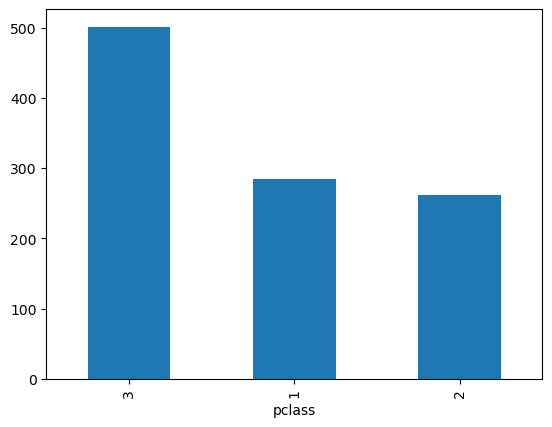

In [68]:
titanic['pclass'].value_counts().plot.bar()

### Repartition des ages suivant un hist 

<Axes: ylabel='Frequency'>

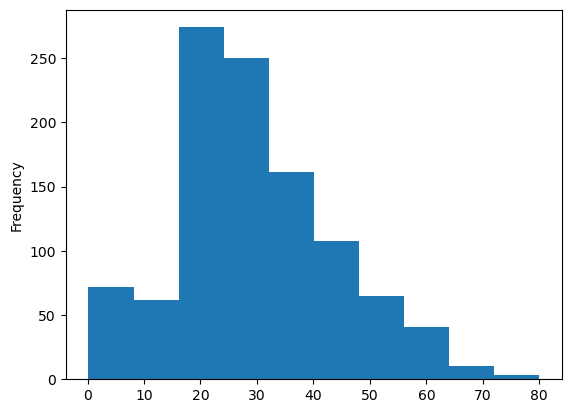

In [72]:
titanic['age'].plot.hist()

La majeur partie des passagers avait un age compris entre 18 et 25 ans.

### Moyenne des éléments suivant le sexe

In [79]:
age_moy = titanic.groupby('sex').mean()
age_moy

,pclass,survived,age
sex,,,
female,2.048969,0.752577,28.687071
male,2.300912,0.205167,30.585233


**75% des femmes ont survecu contre 20% pour les hommmes**

### Moyenne des elements suivant le sexe et la classe

In [81]:
enquete = titanic.groupby(['sex', 'pclass']).mean()
enquete

survived        age
sex    pclass                     
female 1       0.962406  37.037594
       2       0.893204  27.499191
       3       0.473684  22.185307
male   1       0.350993  41.029250
       2       0.145570  30.815401
       3       0.169054  25.962273

**Les hommes de la first class a une moyenne de survie plus basse que les femmes de la third class (47 > 35)**